In [ ]:
import sys
sys.path.insert(0, '../src')

import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from data import TorchvisionDatamodule
from mae import MultiViewMAE
from task.MAETask import MAETask
from util.model_loading import load_from_config

In [ ]:
CONFIG_PATH = "/data/thallybu/mlops/mlflow/run-artifacts/142828242641638217/7fe26b47fcfb4b57b18c7f9ac8af01fc/artifacts/config.yaml"
CHECKPOINT_PATH = "/data/thallybu/mlops/mlflow/run-artifacts/142828242641638217/7fe26b47fcfb4b57b18c7f9ac8af01fc/artifacts/last/last.ckpt"
model, data = load_from_config(CONFIG_PATH, CHECKPOINT_PATH)
model.eval()

In [65]:
from feature_extractors import MAEFeatureExtractor

feature_extractor = MAEFeatureExtractor.from_checkpoint(CHECKPOINT_PATH)
feature_extractor

torch.Size([64, 1, 224, 224])


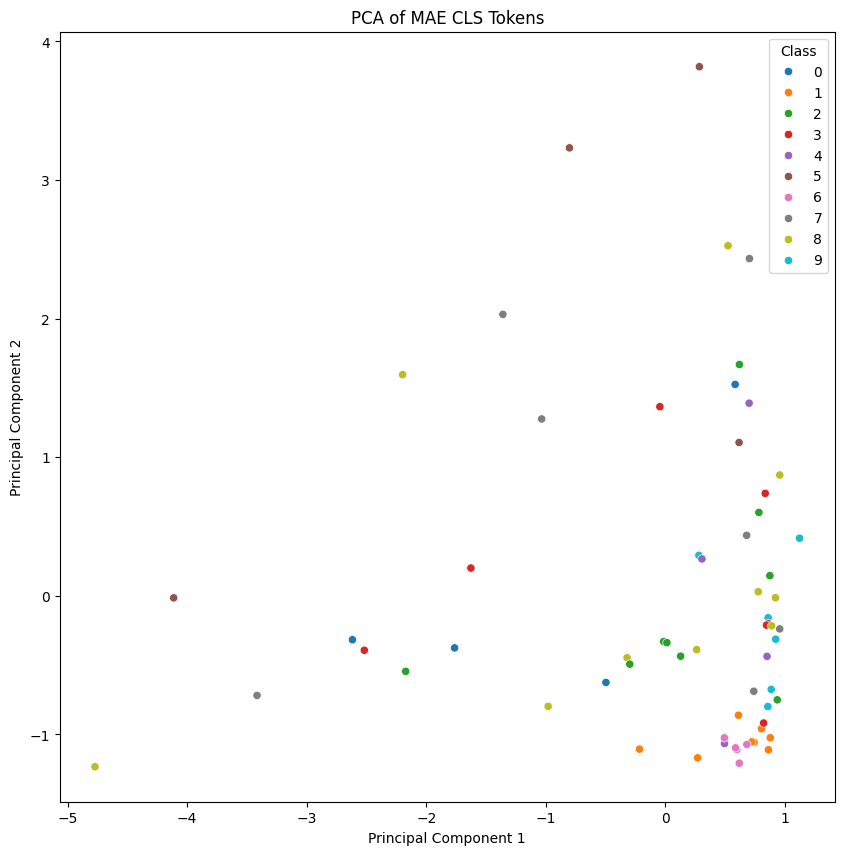

In [67]:
# test the model on a batch of data
dm = TorchvisionDatamodule(
    dataset_name="EMNIST",
    root_dir="/data/thallybu/datasets/EMNIST",
    emnist_split="digits",
    img_mode="L",
    img_size=(224, 224),
    batch_size=64,
    num_workers=0,  # Set to 0 for notebook debugging
    train_val_split=(0.9, 0.1),
)

# Setup the datamodule
dm.prepare_data()
dm.setup(stage="fit")

images, y, ids = next(iter(dm.train_dataloader()))


print(images.shape)  # should be (batch_size, channels, height, width)
with torch.no_grad():
    features = feature_extractor.extract(images)

# PCA on the cls tokens color code them based on their class labels
cls_tokens = features.cpu().numpy()
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
cls_tokens_2d = pca.fit_transform(cls_tokens)
plt.figure(figsize=(10, 10))
sns.scatterplot(x=cls_tokens_2d[:, 0], y=cls_tokens_2d[:, 1], hue=y.cpu().numpy(), palette="tab10")
plt.title("PCA of MAE CLS Tokens")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Class")
plt.show()
